# **About this Dataset**
# Context
The FIFA World Cup is the most prestigious football tournament in the world. The championship has been awarded every four years since the start of the tournament in 1930.

The current format involves a qualification phase, which takes place over the preceding three years, to determine which teams quality for the tournament. In the tournament, 32 teams, including the host nation, compete for the title at different stadiums in the host country.

The reigning champion is France, which beat Croatia in the 2018 tournament in Russia. Qatar will host the 2022 tournament, for which the first match will be played in November.

This dataset provides a complete overview of all international soccer matches played since the 90s. On top of that, the strength of each team is provided by incorporating actual FIFA rankings as well as player strengths based on the EA Sport FIFA video game.

# **Some suggestions**
1. Can you predict what team is most likely to win the 2022 FIFA World Cup?
2. What team has the strongest defense, midfield, and offense players?
3. Is there really such a thing as a home team advantage?
4. Do teams with stronger offense players score more goals? And do teams with stronger goalkeepers receive fewer goals?
5. What team has the longest winning streak?
6. Does the best team always win? Can you explain why a weaker team sometimes win?

In [2]:
pip install plotly


   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.1/16.4 MB 2.6 MB/s eta 0:00:07
    --------------------------------------- 0.2/16.4 MB 3.0 MB/s eta 0:00:06
    --------------------------------------- 0.4/16.4 MB 2.8 MB/s eta 0:00:06
   - -------------------------------------- 0.5/16.4 MB 2.4 MB/s eta 0:00:07
   - -------------------------------------- 0.6/16.4 MB 2.5 MB/s eta 0:00:07
   - -------------------------------------- 0.7/16.4 MB 2.6 MB/s eta 0:00:07
   - -------------------------------------- 0.8/16.4 MB 2.6 MB/s eta 0:00:07
   -- ------------------------------------- 0.9/16.4 MB 2.3 MB/s eta 0:00:07
   -- ------------------------------------- 1.1/16.4 MB 2.5 MB/s eta 0:00:07
   -- ------------------------------------- 1.2/16.4 MB 2.5 MB/s eta 0:00:07
   --- ------------------------------------ 1.3/16.4 MB 2.5 MB/s eta 0:00:07
   --- ------------------------------------ 1.4/16.4 MB 2.5 MB/s eta 0:00:07
   --

In [3]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("international_matches.csv")


# Data Preprocessing

In [4]:
df.head()

,date,home_team,away_team,home_team_continent,away_team_continent,home_team_fifa_rank,away_team_fifa_rank,home_team_total_fifa_points,away_team_total_fifa_points,home_team_score,...,shoot_out,home_team_result,home_team_goalkeeper_score,away_team_goalkeeper_score,home_team_mean_defense_score,home_team_mean_offense_score,home_team_mean_midfield_score,away_team_mean_defense_score,away_team_mean_offense_score,away_team_mean_midfield_score
0,1993-08-08,Bolivia,Uruguay,South America,South America,59,22,0,0,3,...,No,Win,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-08-08,Brazil,Mexico,South America,North America,8,14,0,0,1,...,No,Draw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-08-08,Ecuador,Venezuela,South America,South America,35,94,0,0,5,...,No,Win,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-08-08,Guinea,Sierra Leone,Africa,Africa,65,86,0,0,1,...,No,Win,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-08-08,Paraguay,Argentina,South America,South America,67,5,0,0,1,...,No,Lose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print(df.columns)

Index(['date', 'home_team', 'away_team', 'home_team_continent',
       'away_team_continent', 'home_team_fifa_rank', 'away_team_fifa_rank',
       'home_team_total_fifa_points', 'away_team_total_fifa_points',
       'home_team_score', 'away_team_score', 'tournament', 'city', 'country',
       'neutral_location', 'shoot_out', 'home_team_result',
       'home_team_goalkeeper_score', 'away_team_goalkeeper_score',
       'home_team_mean_defense_score', 'home_team_mean_offense_score',
       'home_team_mean_midfield_score', 'away_team_mean_defense_score',
       'away_team_mean_offense_score', 'away_team_mean_midfield_score'],
      dtype='object')


# Statistical Summary

In [7]:
df.describe()

,home_team_fifa_rank,away_team_fifa_rank,home_team_total_fifa_points,away_team_total_fifa_points,home_team_score,away_team_score,home_team_goalkeeper_score,away_team_goalkeeper_score,home_team_mean_defense_score,home_team_mean_offense_score,home_team_mean_midfield_score,away_team_mean_defense_score,away_team_mean_offense_score,away_team_mean_midfield_score
count,23921.000000,23921.000000,23921.000000,23921.000000,23921.000000,23921.000000,8379.000000,8095.000000,7787.000000,8510.000000,8162.000000,7564.000000,8312.000000,7979.000000
mean,77.854688,80.797375,323.401488,315.453576,1.609214,1.068266,74.963838,74.212477,74.903249,75.818743,75.889292,74.424379,75.420019,75.259143
std,52.355225,53.232902,500.825725,490.944273,1.630127,1.263944,8.212242,8.225919,6.003114,6.268416,6.053110,5.937425,6.201906,6.124573
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,47.000000,47.000000,52.800000,53.300000,54.200000,52.800000,53.300000,54.200000
25%,33.000000,36.000000,0.000000,0.000000,0.000000,0.000000,70.000000,69.000000,71.000000,71.700000,72.500000,70.500000,71.300000,71.800000
50%,71.000000,73.000000,0.000000,0.000000,1.000000,1.000000,75.000000,74.000000,75.200000,75.700000,76.200000,74.500000,75.300000,75.500000
75%,115.000000,119.000000,547.000000,523.000000,2.000000,2.000000,81.000000,80.000000,78.800000,80.000000,79.500000,78.200000,79.700000,79.000000
max,211.000000,211.000000,2164.000000,2164.000000,31.000000,21.000000,97.000000,97.000000,91.800000,93.000000,93.200000,91.800000,93.000000,93.200000


# **Feature Engineering**

In [8]:
import pandas as pd

# Assuming df is your DataFrame containing the newly engineered columns along with the original columns

# Feature Engineering
df['goalkeeper_score'] = df['home_team_goalkeeper_score'] - df['away_team_goalkeeper_score']
df['defense_score'] = df['home_team_mean_defense_score'] - df['away_team_mean_defense_score']
df['midfield_score'] = df['home_team_mean_midfield_score'] - df['away_team_mean_midfield_score']
df['offense_score'] = df['home_team_mean_offense_score'] - df['away_team_mean_offense_score']

# Drop previous columns
columns_to_drop = ['home_team_goalkeeper_score', 'away_team_goalkeeper_score',
                  'home_team_mean_defense_score', 'away_team_mean_defense_score', 'home_team_mean_midfield_score', 'away_team_mean_midfield_score',
                  'home_team_mean_offense_score', 'away_team_mean_offense_score']

# Drop columns only if they exist in the DataFrame
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df.drop(columns=columns_to_drop, inplace=True)

# Display the updated DataFrame
df.head()

,date,home_team,away_team,home_team_continent,away_team_continent,home_team_fifa_rank,away_team_fifa_rank,home_team_total_fifa_points,away_team_total_fifa_points,home_team_score,...,tournament,city,country,neutral_location,shoot_out,home_team_result,goalkeeper_score,defense_score,midfield_score,offense_score
0,1993-08-08,Bolivia,Uruguay,South America,South America,59,22,0,0,3,...,FIFA World Cup qualification,La Paz,Bolivia,False,No,Win,NaN,NaN,NaN,NaN
1,1993-08-08,Brazil,Mexico,South America,North America,8,14,0,0,1,...,Friendly,Maceió,Brazil,False,No,Draw,NaN,NaN,NaN,NaN
2,1993-08-08,Ecuador,Venezuela,South America,South America,35,94,0,0,5,...,FIFA World Cup qualification,Quito,Ecuador,False,No,Win,NaN,NaN,NaN,NaN
3,1993-08-08,Guinea,Sierra Leone,Africa,Africa,65,86,0,0,1,...,Friendly,Conakry,Guinea,False,No,Win,NaN,NaN,NaN,NaN
4,1993-08-08,Paraguay,Argentina,South America,South America,67,5,0,0,1,...,FIFA World Cup qualification,Asunción,Paraguay,False,No,Lose,NaN,NaN,NaN,NaN


# **Remove Missing Values**

In [9]:
df['goalkeeper_score'] = df['goalkeeper_score'].fillna(df['goalkeeper_score'].median())
df['defense_score'] = df['defense_score'].fillna(df['defense_score'].median())
df['midfield_score'] = df['midfield_score'].fillna(df['midfield_score'].median())
df['offense_score'] = df['offense_score'].fillna(df['offense_score'].median())
df.isnull().sum()

date                           0
home_team                      0
away_team                      0
home_team_continent            0
away_team_continent            0
home_team_fifa_rank            0
away_team_fifa_rank            0
home_team_total_fifa_points    0
away_team_total_fifa_points    0
home_team_score                0
away_team_score                0
tournament                     0
city                           0
country                        0
neutral_location               0
shoot_out                      0
home_team_result               0
goalkeeper_score               0
defense_score                  0
midfield_score                 0
offense_score                  0
dtype: int64

# Data Visualization

### "I have checked the data through a pair plot and found that it is not linear; there is significant overlap. Unfortunately, I cannot show the diagram due to memory constraints in this notebook."

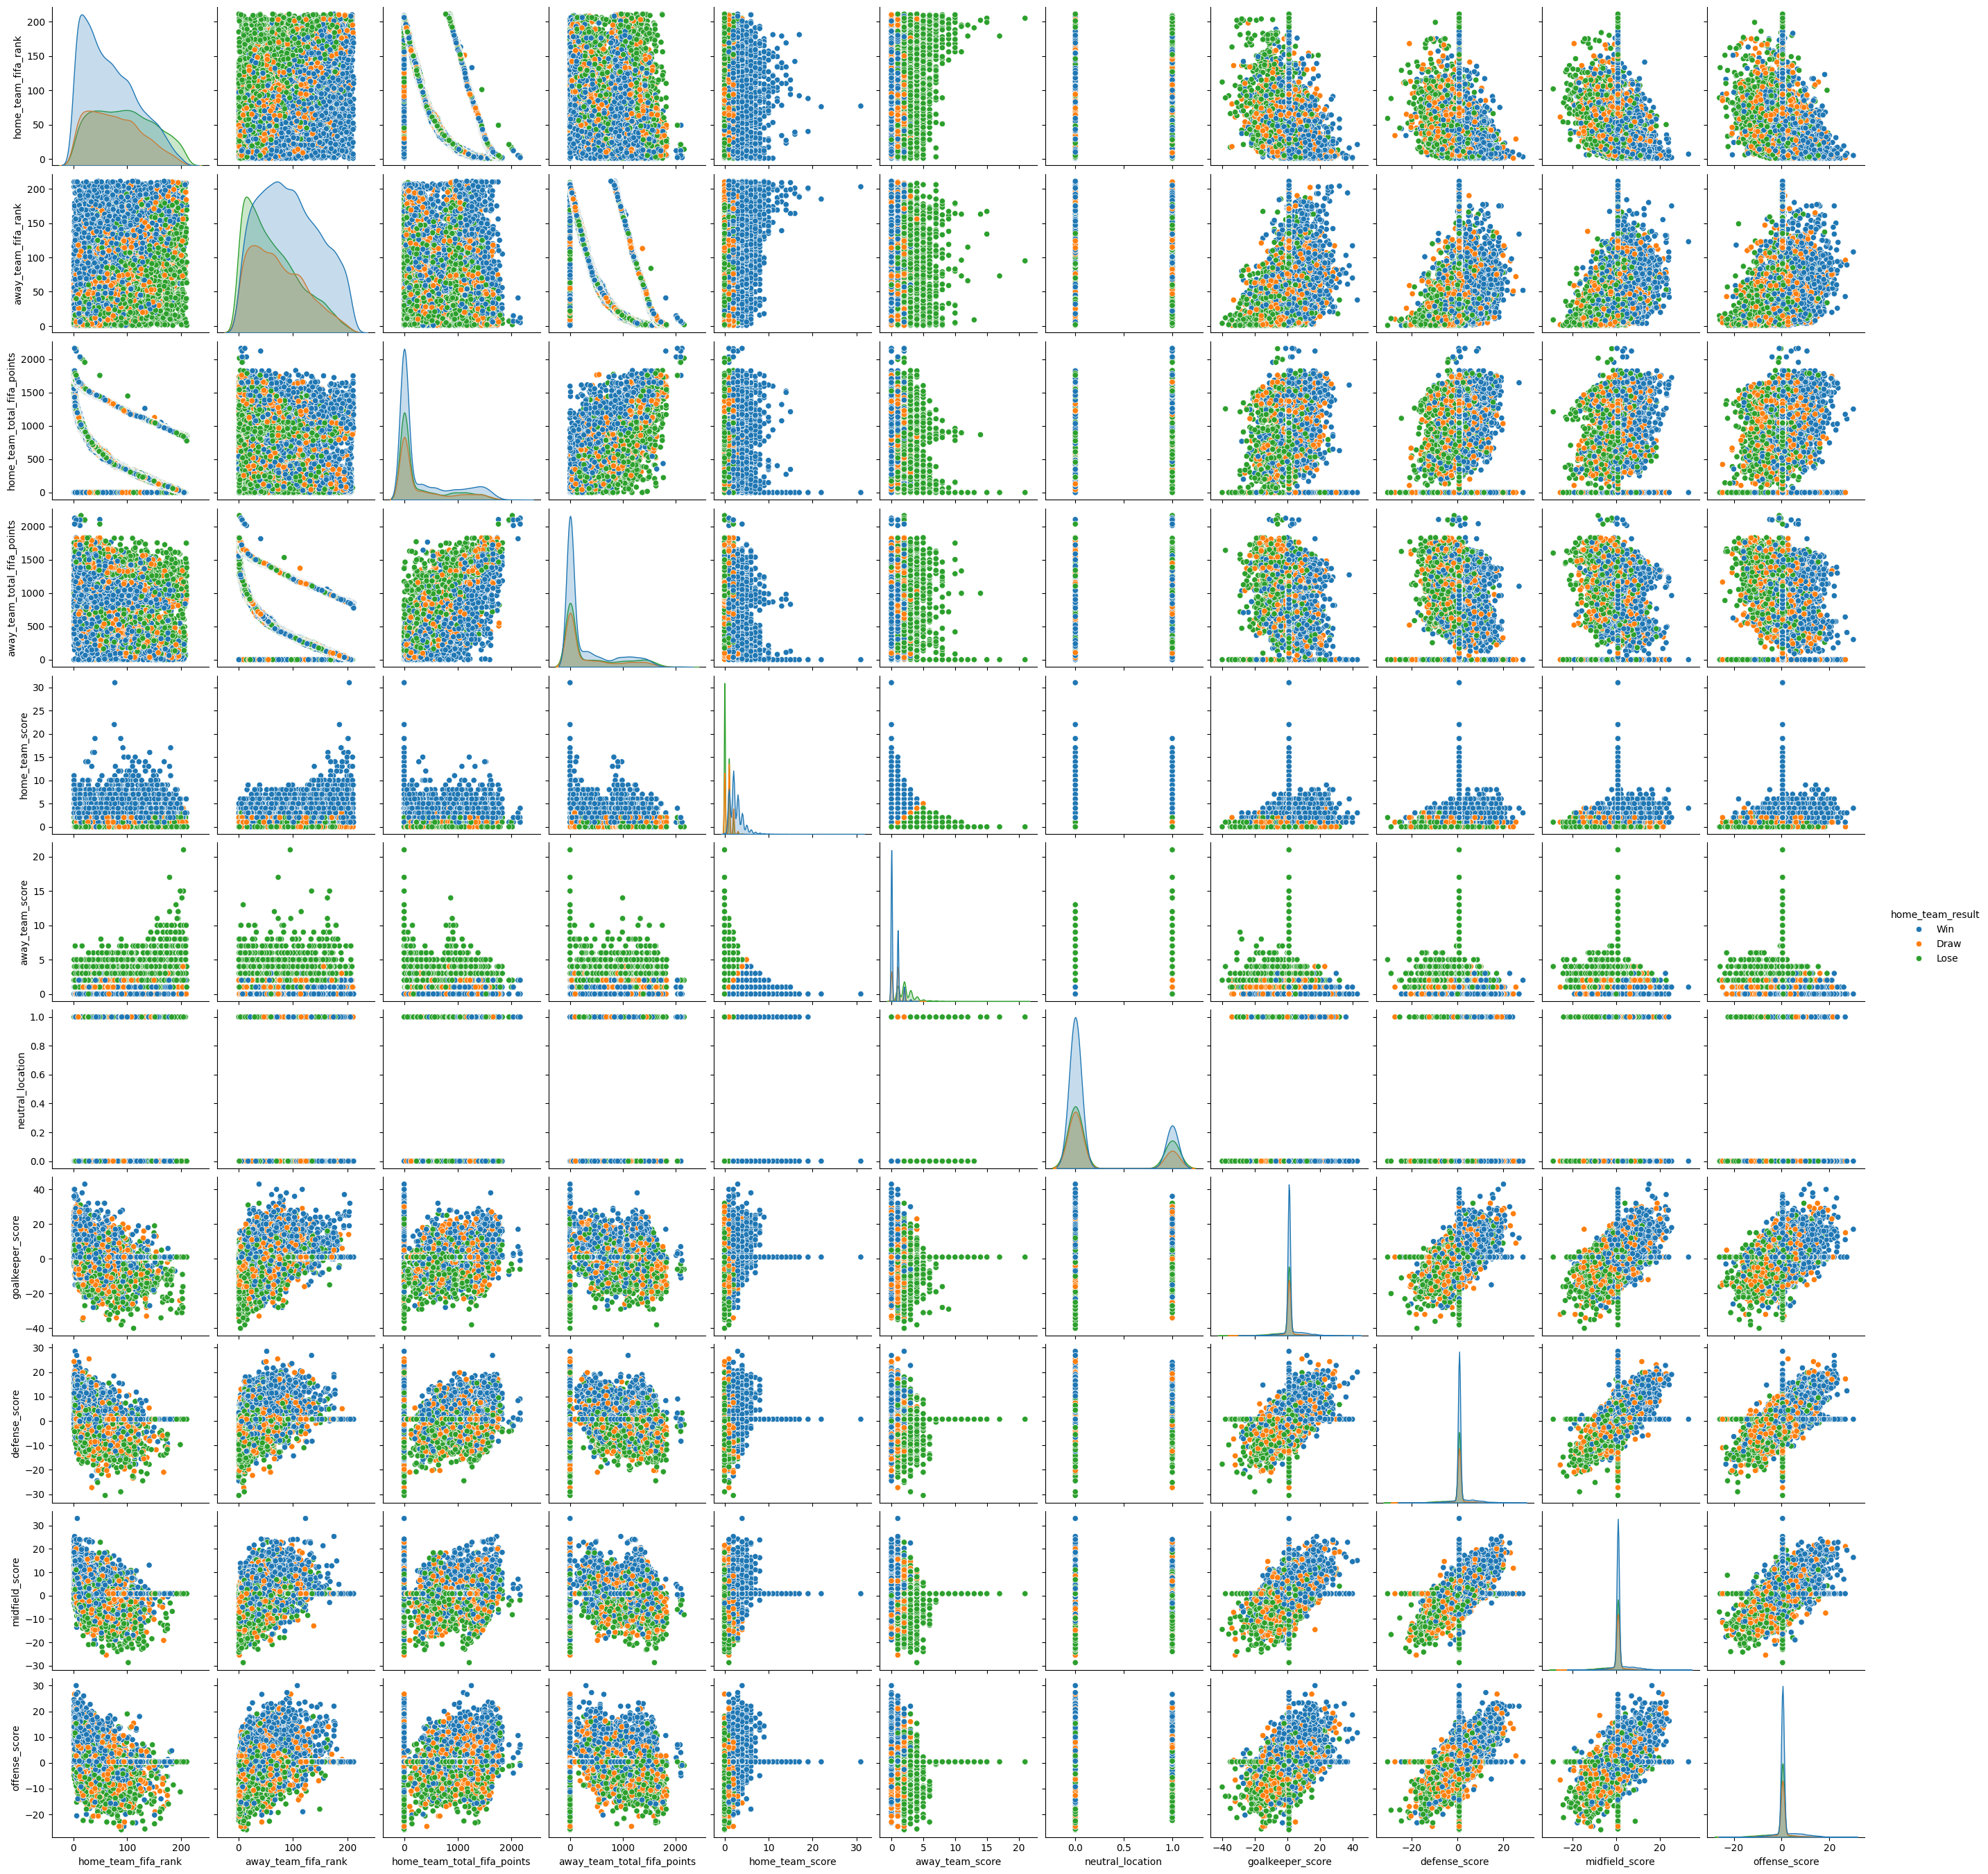

In [10]:
# pairplot
sns.pairplot(df, hue='home_team_result')

### We can observe that in some columns, the model shows a linear pattern, while in other cases, the model exhibits overlapping.

# scatter plot cheking for relationship between 2 variables

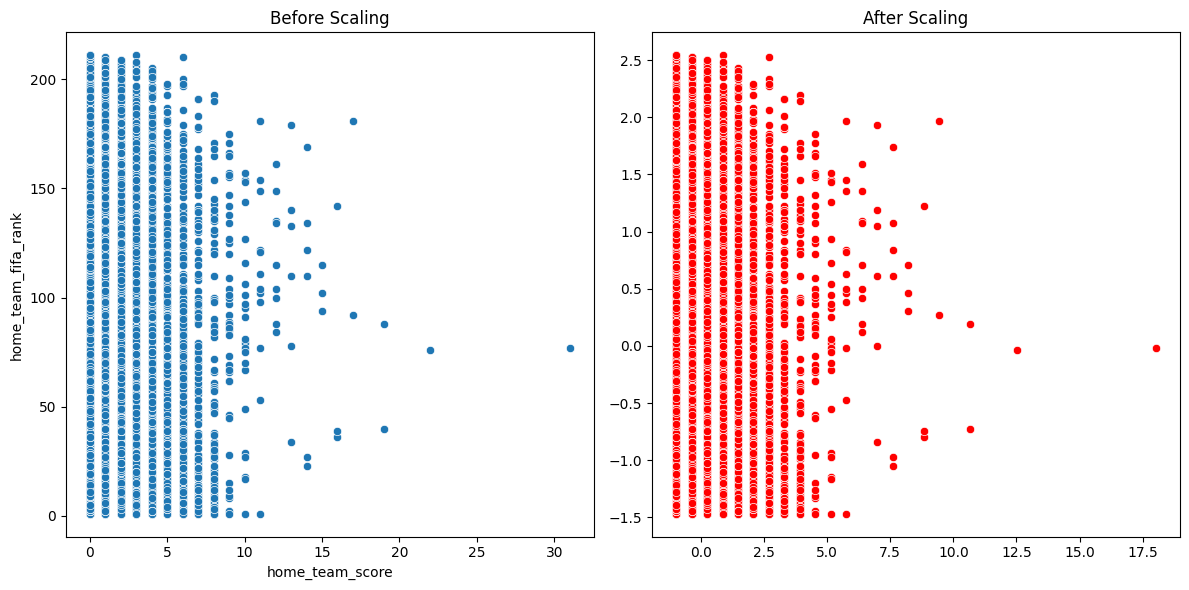

In [11]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Original scatter plot without scaling
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='home_team_score', y='home_team_fifa_rank')  
plt.title('Before Scaling')

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['home_team_score', 'home_team_fifa_rank']])

# Scatter plot with scaled data
plt.subplot(1, 2, 2)
sns.scatterplot(x=scaled_data[:, 0], y=scaled_data[:, 1], color='red')
plt.title('After Scaling')

# Show the plot
plt.tight_layout()
plt.show()


# box plot for checking outlier

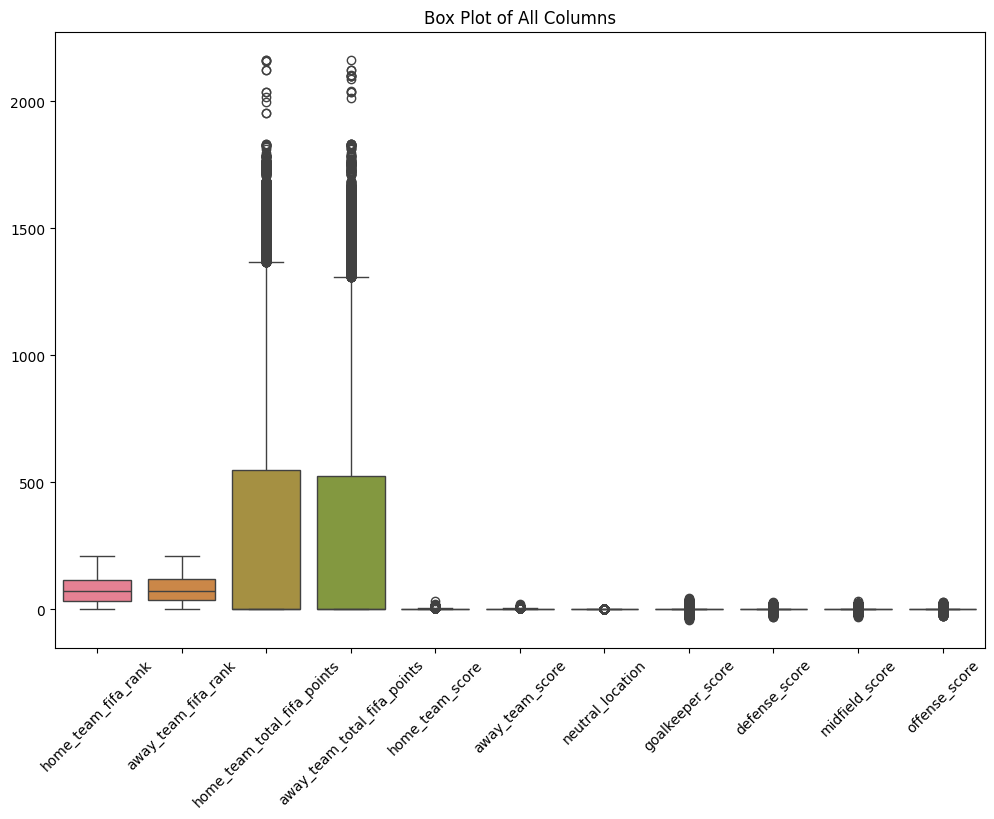

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Creating box plots for all columns
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.title('Box Plot of All Columns')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


## **removing outlier with IQR**

In [13]:
# Define a function to remove outliers using IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers
df_cleaned = remove_outliers(df, 'home_team_total_fifa_points')
df_cleaned = remove_outliers(df_cleaned, 'away_team_total_fifa_points')

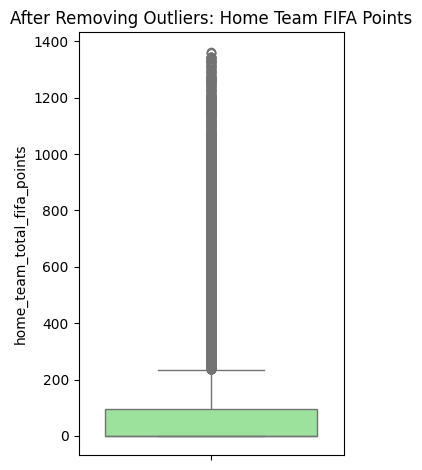

In [14]:
plt.subplot(1, 2, 2)
sns.boxplot(data=df_cleaned, y='home_team_total_fifa_points', color='lightgreen')
plt.title('After Removing Outliers: Home Team FIFA Points')

plt.tight_layout()
plt.show()

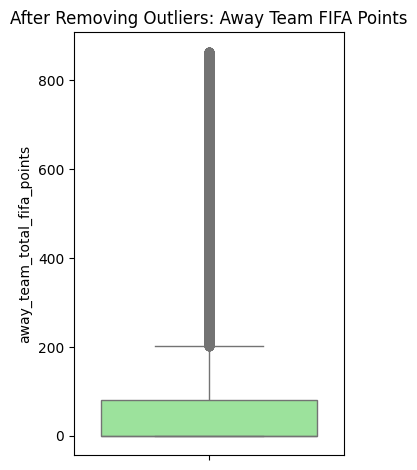

In [15]:
plt.subplot(1, 2, 2)
sns.boxplot(data=df_cleaned, y='away_team_total_fifa_points', color='lightgreen')
plt.title('After Removing Outliers: Away Team FIFA Points')

plt.tight_layout()
plt.show()

### successfully removed outlier in two categories.

# funnel:
Funnel charts are often used to represent data in different stages of a business process. It’s an important mechanism in Business Intelligence to identify potential problem areas of a process.

In [30]:
# Create the funnel plot
fig = px.funnel(df, x='home_team_fifa_rank', y='home_team_result', color='home_team_result')
fig.show()

# pie plot
### A pie chart is a circular statistical chart, which is divided into sectors to illustrate numerical proportion.

In [31]:
import plotly.express as px

# Assuming df is your DataFrame
fig = px.pie(df, values='home_team_score', names='home_team_result', title='Results of Home Team')
fig.show()

### Now checking the results of home team

In [32]:
# Assuming df is your DataFrame
# fig = px.pie(df, values='home_team_total_fifa_points', names='home_team_result', title='Results of Home Team', pull=[0, 0, 0.2, 0])
# fig.show()
import plotly.graph_objects as go
# pull is given as a fraction of the pie radius
# Assuming df is your DataFrame
fig = go.Figure(data=[go.Pie(values=df['home_team_total_fifa_points'], 
                             labels=df['home_team_continent'], 
                             title='Results of Home Team', 
                             pull=[0, 0, 0.2, 0])])
fig.show()

### check distribution of FIFA Wolrd Cup from 2000 to 2023

In [34]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(1, 2, specs=[[{'type':'domain'}, {'type':'domain'}]],
                    subplot_titles=['2000', '2023'])

# Assuming df is your DataFrame
fig.add_trace(go.Pie(values=df['home_team_fifa_rank'], labels=df['home_team_result'], scalegroup='one',
                     name="FIFA World cup 2000"), 1, 1)
fig.add_trace(go.Pie(values=df['away_team_fifa_rank'], labels=df['home_team_result'], scalegroup='one',
                     name="FIFA World cup 2023"), 1, 2)

fig.update_layout(title_text='FIFA World cup 2000 to 2023')
fig.show()


### which team take highest rank in 2022?

In [35]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

labels = ["Mexico", "USA", "Germany"]

fig = make_subplots(1, 2, specs=[[{'type':'domain'}, {'type':'domain'}]],
                    subplot_titles=['home team rank 2022', 'away team rank 2022'])

# Assuming df is your DataFrame
fig.add_trace(go.Pie(values=df['home_team_fifa_rank'], labels=labels, scalegroup='one',
                     name="home team rank 2022"), 1, 1)
fig.add_trace(go.Pie(values=df['away_team_fifa_rank'], labels=labels, scalegroup='one',
                     name="away team rank 2022"), 1, 2)

fig.update_layout(title_text='FIFA World cup 2022 to 2022')
fig.show()

In [36]:
# value counts of country
df['country'].value_counts()

country
USA                      1003
South Africa              505
United Arab Emirates      462
Qatar                     461
France                    445
                         ... 
Réunion                     2
Afghanistan                 2
Tahiti                      2
Saint Martin                2
Serbia and Montenegro       1
Name: count, Length: 217, dtype: int64

# which country take highest rank in 2023

In [37]:
labels = ["USA", "South Africa", "United Arab Emirates", "Qatar", "France", "Réunion", "Afghanistan", "Tahiti",
          "Saint Martin", "Serbia and Montenegro"]

fig = make_subplots(1, 2, specs=[[{'type':'domain'}, {'type':'domain'}]],
                    subplot_titles=['home team rank 2023', 'away team rank 2023'])

# Assuming df is your DataFrame
fig.add_trace(go.Pie(values=df['home_team_fifa_rank'], labels=labels, scalegroup='one',
                     name="home team rank 2023"), 1, 1)
fig.add_trace(go.Pie(values=df['away_team_fifa_rank'], labels=labels, scalegroup='one',
                     name="away team rank 2023"), 1, 2)

fig.update_layout(title_text='FIFA World cup 2023 to 2023')
fig.show()

In [38]:
# home team score
df['home_team_score'].value_counts()

home_team_score
1     7229
0     6273
2     5263
3     2613
4     1330
5      583
6      292
7      142
8       84
9       43
10      24
11      12
12       9
13       6
14       6
16       3
15       3
19       2
17       2
22       1
31       1
Name: count, dtype: int64

# Sunbrust
### which team takes highest score?

In [39]:
import plotly.graph_objects as go

# Define data for Sunburst chart
labels=["USA", "South Africa", "United Arab Emirates", "Qatar", "France", "Réunion", "Afghanistan", "Tahiti", "Saint Martin", "Serbia and Montenegro"]
parents=["", "USA", "South Africa", "United Arab Emirates", "Qatar", "France", "Réunion", "Afghanistan", "Tahiti", "Saint Martin"]
values=[7229, 6273, 5263, 2613, 1330, 583, 292, 142, 84, 43, 24, 12, 9, 6, 6, 3, 3, 2, 2, 1, 1]  # Example values

# Create Sunburst chart
fig = go.Figure(go.Sunburst(
    labels=labels,
    parents=parents,
    values=values,
))

# Update layout
fig.update_layout(margin=dict(t=0, l=0, r=0, b=0))

# Show figure
fig.show()


# Histogram
### distribution of variable


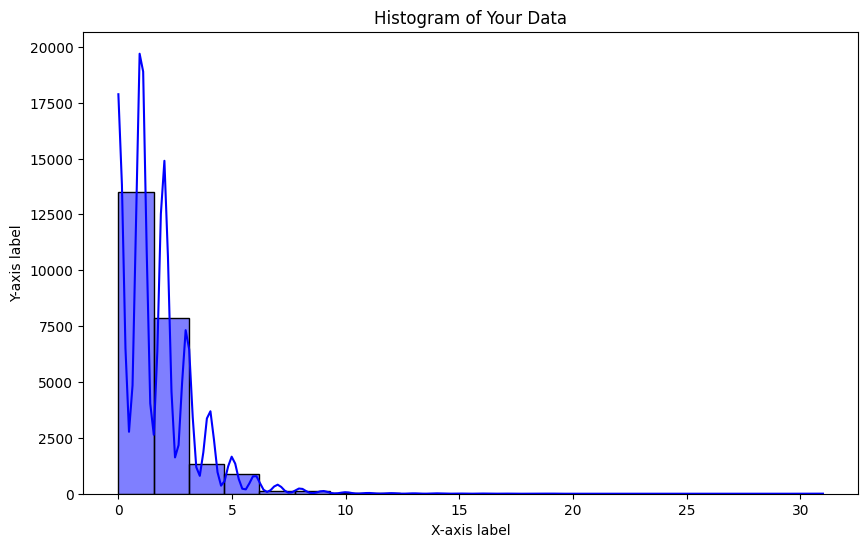

In [40]:
# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['home_team_score'], bins=20, kde=True, color='blue')
plt.title('Histogram of Your Data')
plt.xlabel('X-axis label')
plt.ylabel('Y-axis label')
plt.show()

# Distribution of team continent, rank, points and their score

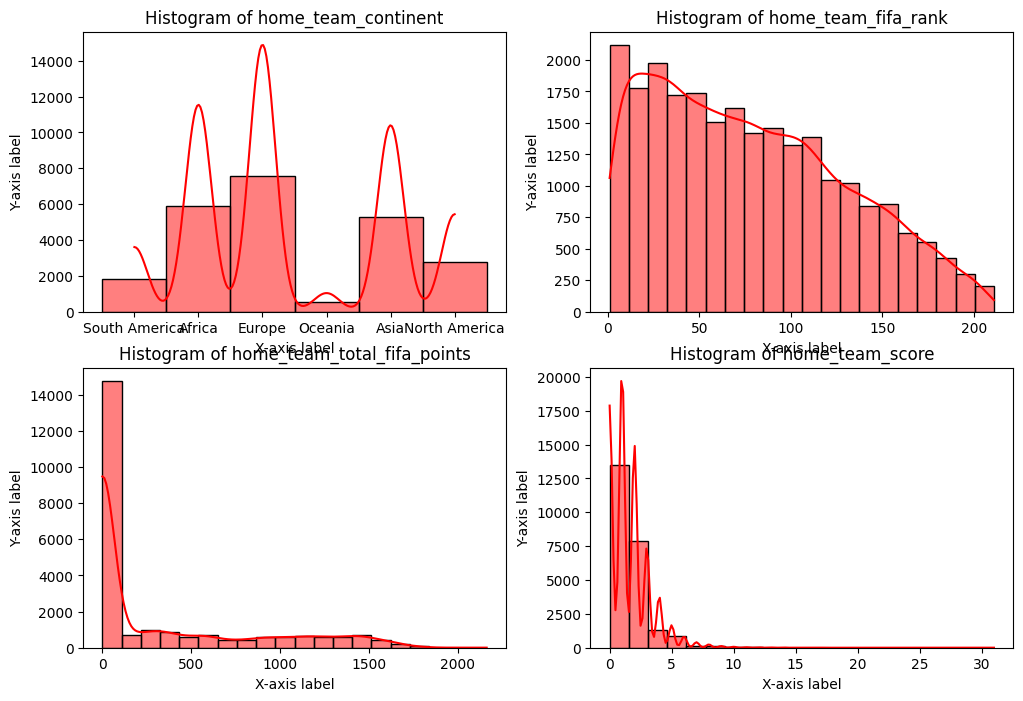

In [41]:
# Define the features you want to plot
features = ['home_team_continent', 'home_team_fifa_rank', 'home_team_total_fifa_points', 'home_team_score']

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate through each feature and plot its histogram
for i, feature in enumerate(features):
    sns.histplot(df[feature], bins=20, kde=True, color='red', ax=axes[i])
    axes[i].set_title(f'Histogram of {feature}')
    axes[i].set_xlabel('X-axis label')
    axes[i].set_ylabel('Y-axis label')

# we will transformation on home_team_score

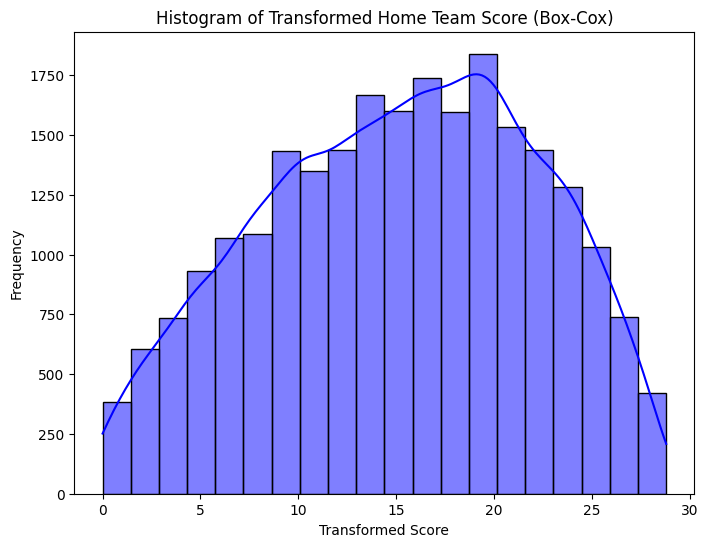

In [42]:
from scipy.stats import boxcox

# Perform Box-Cox transformation on 'home_team_score'
transformed_score, lambda_value = boxcox(df['home_team_fifa_rank'])

# Plot the histogram of the transformed data
plt.figure(figsize=(8, 6))
sns.histplot(transformed_score, bins=20, kde=True, color='blue')
plt.title('Histogram of Transformed Home Team Score (Box-Cox)')
plt.xlabel('Transformed Score')
plt.ylabel('Frequency')
plt.show()


# home_team_continent normalize through count plot

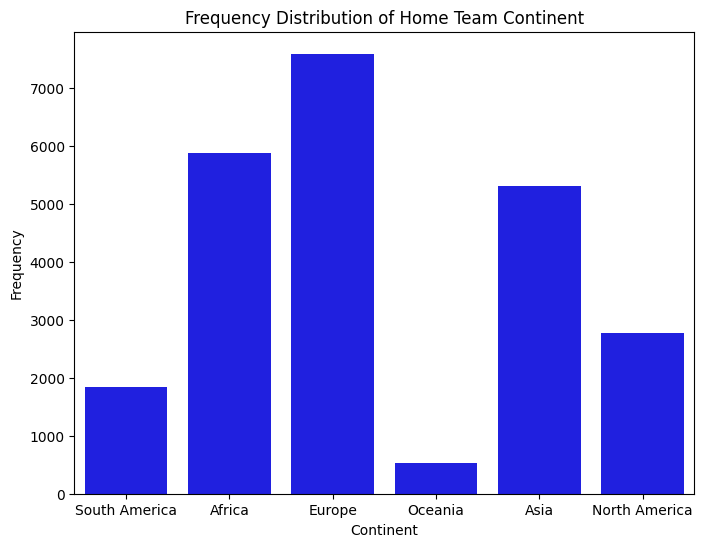

In [43]:
# Plot the frequency distribution of 'home_team_continent'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='home_team_continent', color='blue')
plt.title('Frequency Distribution of Home Team Continent')
plt.xlabel('Continent')
plt.ylabel('Frequency')
plt.show()


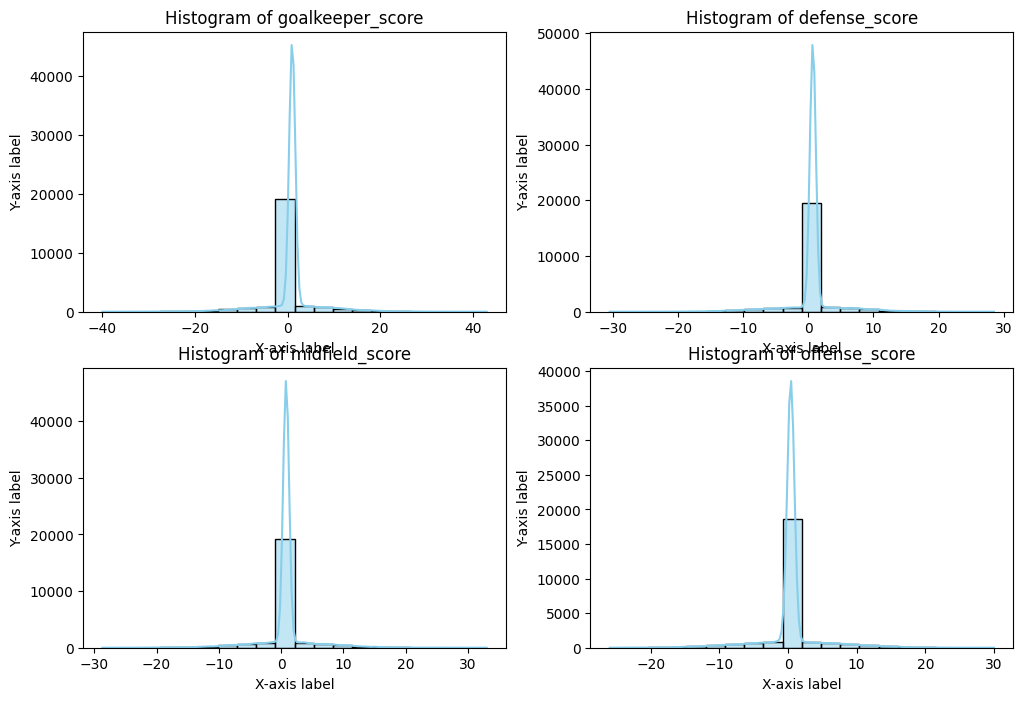

In [44]:
# Define the features you want to plot
features = ['goalkeeper_score', 'defense_score', 'midfield_score', 'offense_score']

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate through each feature and plot its histogram
for i, feature in enumerate(features):
    sns.histplot(df[feature], bins=20, kde=True, color='skyblue', ax=axes[i])
    axes[i].set_title(f'Histogram of {feature}')
    axes[i].set_xlabel('X-axis label')
    axes[i].set_ylabel('Y-axis label')

# heatmap plot for distribution

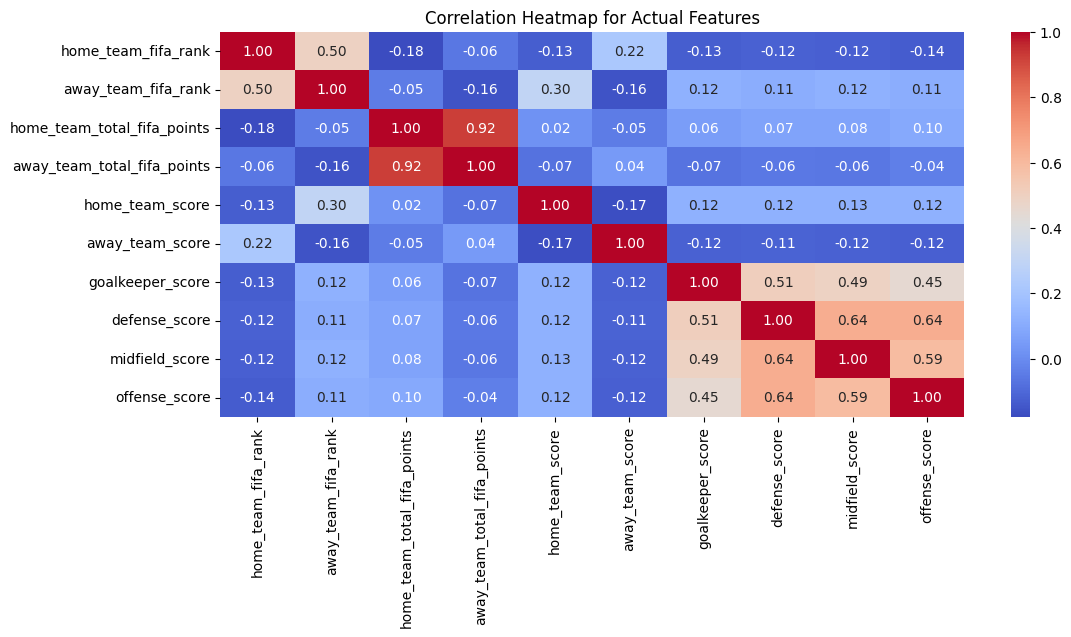

In [16]:
# Select the relevant features from your DataFrame
selected_features = ['home_team_fifa_rank', 'away_team_fifa_rank',
                     'home_team_total_fifa_points', 'away_team_total_fifa_points',
                     'home_team_score', 'away_team_score', 'goalkeeper_score',
                     'defense_score', 'midfield_score', 'offense_score']

# Extract the correlation matrix for the selected features
correlation_matrix_actual = df[selected_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(correlation_matrix_actual, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Correlation Heatmap for Actual Features')
plt.show()

# Obs:
This graph is a correlation heatmap, which visually represents the correlation coefficients between different features or variables. Correlation coefficients range from -1 to 1, where:

1 indicates a perfect positive correlation: as one variable increases, the other variable also increases.
-1 indicates a perfect negative correlation: as one variable increases, the other variable decreases.
0 indicates no correlation: the variables do not affect each other.
Here’s a detailed explanation of the heatmap:

# Heatmap Structure
1. **Axes:** Both the x-axis and y-axis list the features being compared, such as home_team_fifa_rank, away_team_fifa_rank, home_team_total_fifa_points, etc.
2. **Color Gradient:** The colors range from red to blue:
Red indicates a strong positive correlation.
Blue indicates a strong negative correlation.
Lighter shades indicate weaker correlations.
3. **Values:** Each cell shows the correlation coefficient between the features on the x and y axes.

# Feature Correlations
1. Home Team FIFA Rank vs. Away Team FIFA Rank: 
     - Correlation: 0.50
     - Interpretation: There is a moderate positive correlation between the FIFA rankings of home and away teams.
2. Home Team Total FIFA Points vs. Away Team Total FIFA Points: 
     - Correlation: 0.92
     - Interpretation: There is a very strong positive correlation between the total FIFA points of home and away teams, suggesting   that teams with high points tend to play against each other.

3. Home Team FIFA Rank vs. Home Team Total FIFA Points:
     - Correlation: -0.18
     - Interpretation: There is a weak negative correlation, indicating that higher-ranked (lower numeric rank) home teams tend to have more FIFA points.
4. Home Team Score vs. Away Team Score:
    - Correlation: -0.17
    - Interpretation: There is a weak negative correlation, suggesting that higher scores by one team slightly correlate with lower scores by the other team.

5. Goalkeeper Score vs. Defense Score:
    - Correlation: 0.51
    - Interpretation: There is a moderate positive correlation, indicating that teams with good goalkeepers also tend to have good defense scores.
6. Defense Score vs. Midfield Score:
    - Correlation: 0.64
    - Interpretation: There is a strong positive correlation, suggesting that teams with strong defenses also tend to have strong midfielders.

# General Observations
- Strongest Positive Correlations: These are indicated by the darkest red cells, such as the correlation between home_team_total_fifa_points and away_team_total_fifa_points (0.92).
- Strongest Negative Correlations: These are indicated by the darkest blue cells, such as the correlation between home_team_fifa_rank and home_team_total_fifa_points (-0.18). Note that strong negative correlations are relatively weak in this heatmap.